<div style="border: 5px solid black; padding: 20px; border-radius: 6px;">

## **Course:** DSC640 - Data Presentation and Visualization
## **Name:** Tim Hollis
## **Assignment:** Week 9 & 10
## **Date:** August 5, 2026

---

**References:**

Data Liberation Project. (2023). *TSA complaint counts* [Data set]. GitHub. https://github.com/data-liberation-project/tsa-complaint-counts

IP2Location. (2024). *IATA/ICAO airport codes and locations* [Data set]. GitHub. https://github.com/ip2location/ip2location-iata-icao

Knaflic, C. N. (2015). *Storytelling with data: A data visualization guide for business professionals*. John Wiley & Sons.

</div>

### **Initial Setup**

In [1]:
# Libraries/Imports
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import plotly.graph_objects as go
from IPython.display import Image

# Hide irrelevant noise
warnings.filterwarnings('ignore')

# File paths/Output folder
DATA_DIR = Path('.')
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

# Colorblind-safe Palette
ROYAL_BLUE = '#4169E1'
PURPLE = '#4B0082'
FOREST_GREEN = '#228B22'
AMBER = '#E69F00'
LIGHT_GRAY = '#D3D3D3'
DARK_GRAY = '#4D4D4D'

PALETTE = [ROYAL_BLUE, AMBER, PURPLE, FOREST_GREEN, DARK_GRAY, LIGHT_GRAY]
SEQUENTIAL_CMAP = [[0.0, '#F2F2F2'], [0.5, ROYAL_BLUE], [1.0, PURPLE]]

# DataFrame display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Formatting for visuals
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = LIGHT_GRAY
plt.rcParams['grid.alpha'] = 0.6
plt.rcParams['axes.axisbelow'] = True
sns.set_palette(PALETTE)

THOUSANDS = mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')

# Load datasets
FILES = {
    'airport': 'complaints-by-airport.csv',
    'category': 'complaints-by-category.csv',
    'subcategory': 'complaints-by-subcategory.csv',
    'iata': 'iata-icao.csv',
}

raw = {}
print('📥 Loading source files')
for key, fname in FILES.items():
    raw[key] = pd.read_csv(DATA_DIR / fname)
    rows, cols = raw[key].shape
    print(f'   ✅ {fname:<35} {rows:>8,} rows  x  {cols:>3,} cols')

print('\n🔎 Structure inventory')
for key, df in raw.items():
    print(f'\n📄 {key.upper()}  ({FILES[key]})')
    print(f'   columns: {list(df.columns)}')
    print(f'   dtypes:  {dict(df.dtypes.astype(str))}')
    print(f'   nulls:   {dict(df.isna().sum())}')
    display(df.head(3))

print('\n🚀 Setup complete, ready to profile the complaint data')

📥 Loading source files
   ✅ complaints-by-airport.csv             41,721 rows  x    4 cols
   ✅ complaints-by-category.csv           241,588 rows  x    7 cols
   ✅ complaints-by-subcategory.csv        504,512 rows  x   11 cols
   ✅ iata-icao.csv                          8,937 rows  x    7 cols

🔎 Structure inventory

📄 AIRPORT  (complaints-by-airport.csv)
   columns: ['pdf_report_date', 'airport', 'year_month', 'count']
   dtypes:  {'pdf_report_date': 'str', 'airport': 'str', 'year_month': 'str', 'count': 'int64'}
   nulls:   {'pdf_report_date': np.int64(0), 'airport': np.int64(109), 'year_month': np.int64(0), 'count': np.int64(0)}


,pdf_report_date,airport,year_month,count
0,2019-02,ABE,2015-01,0
1,2019-02,ABE,2015-02,0
2,2019-02,ABE,2015-03,0



📄 CATEGORY  (complaints-by-category.csv)
   columns: ['pdf_report_date', 'airport', 'category', 'year_month', 'count', 'clean_cat', 'clean_cat_status']
   dtypes:  {'pdf_report_date': 'str', 'airport': 'str', 'category': 'str', 'year_month': 'str', 'count': 'int64', 'clean_cat': 'str', 'clean_cat_status': 'str'}
   nulls:   {'pdf_report_date': np.int64(0), 'airport': np.int64(4042), 'category': np.int64(0), 'year_month': np.int64(0), 'count': np.int64(0), 'clean_cat': np.int64(0), 'clean_cat_status': np.int64(0)}


,pdf_report_date,airport,category,year_month,count,clean_cat,clean_cat_status
0,2019-02,ABE,Hazardous Materials Safety,2015-01,0,Hazardous Materials Safety,original
1,2019-02,ABE,Mishandling of Passenger Property,2015-01,0,Mishandling of Passenger Property,original
2,2019-02,ABE,Hazardous Materials Safety,2015-02,0,Hazardous Materials Safety,original



📄 SUBCATEGORY  (complaints-by-subcategory.csv)
   columns: ['pdf_report_date', 'airport', 'category', 'subcategory', 'year_month', 'count', 'clean_cat', 'clean_subcat', 'clean_cat_status', 'clean_subcat_status', 'is_category_prefix_removed']
   dtypes:  {'pdf_report_date': 'str', 'airport': 'str', 'category': 'str', 'subcategory': 'str', 'year_month': 'str', 'count': 'int64', 'clean_cat': 'str', 'clean_subcat': 'str', 'clean_cat_status': 'str', 'clean_subcat_status': 'str', 'is_category_prefix_removed': 'bool'}
   nulls:   {'pdf_report_date': np.int64(0), 'airport': np.int64(13464), 'category': np.int64(0), 'subcategory': np.int64(0), 'year_month': np.int64(0), 'count': np.int64(0), 'clean_cat': np.int64(0), 'clean_subcat': np.int64(0), 'clean_cat_status': np.int64(0), 'clean_subcat_status': np.int64(0), 'is_category_prefix_removed': np.int64(0)}


,pdf_report_date,airport,category,subcategory,year_month,count,clean_cat,clean_subcat,clean_cat_status,clean_subcat_status,is_category_prefix_removed
0,2019-02,ABE,Hazardous Materials Safety,General,2015-01,0,Hazardous Materials Safety,General,original,original,False
1,2019-02,ABE,Mishandling of Passenger Property,Damaged/Missing Items--Checked Baggage,2015-01,0,Mishandling of Passenger Property,*Damaged/Missing Items--Checked Baggage,original,original,False
2,2019-02,ABE,Hazardous Materials Safety,General,2015-02,0,Hazardous Materials Safety,General,original,original,False



📄 IATA  (iata-icao.csv)
   columns: ['country_code', 'region_name', 'iata', 'icao', 'airport', 'latitude', 'longitude']
   dtypes:  {'country_code': 'str', 'region_name': 'str', 'iata': 'str', 'icao': 'str', 'airport': 'str', 'latitude': 'float64', 'longitude': 'float64'}
   nulls:   {'country_code': np.int64(32), 'region_name': np.int64(0), 'iata': np.int64(0), 'icao': np.int64(1143), 'airport': np.int64(0), 'latitude': np.int64(0), 'longitude': np.int64(0)}


,country_code,region_name,iata,icao,airport,latitude,longitude
0,AE,Abu Zaby,AAN,OMAL,Al Ain International Airport,24.26,55.61
1,AE,Abu Zaby,AUH,OMAA,Abu Dhabi International Airport,24.43,54.65
2,AE,Abu Zaby,AYM,NaN,Yas Island Seaplane Base,24.47,54.61



🚀 Setup complete, ready to profile the complaint data


### **Data Profiling**

Before any cleaning, the four sources are profiled for reporting overlap, missing airport codes, and join coverage against the IATA lookup.

In [2]:
# Shorthand handles for the four raw frames
air = raw['airport']
cat = raw['category']
sub = raw['subcategory']
iata = raw['iata']

# Compare how many PDF reports each file draws from vs how many months it
# covers
print('🗓️ Reporting windows')
for name, df in [('airport', air), ('category', cat), ('subcategory', sub)]:
    reports = sorted(df['pdf_report_date'].unique())
    months = sorted(df['year_month'].unique())
    print(
        f'   {name:<12} {len(reports):>3,} PDF reports  ({reports[0]} to {reports[-1]})'
        f'   |  {len(months):>3,} months covered  ({months[0]} to {months[-1]})')

# Check whether any airport-month appears in more than one report, and
# whether reports disagree
print('\n🔁 Overlap check on complaints-by-airport')
pairs = air.groupby(['airport', 'year_month'])[
    'count'].agg(['size', 'nunique'])
print(f'   Unique airport-month pairs: {len(pairs):,}')
print(f'   Total rows:                 {len(air):,}')
print(f'   Pairs appearing more than once: {(pairs["size"] > 1).sum():,}')
print(
    f'   Pairs where reports disagree on the count: {(pairs["nunique"] > 1).sum():,}')

# If any conflicts exist, print one example so the resolution rule can be
# chosen deliberately
conflict = pairs[pairs['nunique'] > 1]
if len(conflict) > 0:
    sample_airport, sample_month = conflict.index[0]
    print(f'\n   Example conflict, {sample_airport} in {sample_month}:')
    display(air[(air['airport'] == sample_airport) & (
        air['year_month'] == sample_month)].sort_values('pdf_report_date'))

# Quantify unattributed rows by count and by the complaint volume they carry
print('\n❓ Rows missing an airport code')
for name, df in [('airport', air), ('category', cat), ('subcategory', sub)]:
    missing = df['airport'].isna().sum()
    share = missing / len(df)
    lost = df.loc[df['airport'].isna(), 'count'].sum()
    print(
        f'   {name:<12} {missing:>7,} rows  ({share:.2%})  carrying {lost:,} complaints')

# Measure how much label consolidation the source authors already applied
print('\n🏷️ Category vocabulary')
print(f'   Raw categories:        {cat["category"].nunique():,}')
print(f'   Cleaned categories:    {cat["clean_cat"].nunique():,}')
print(f'   Raw subcategories:     {sub["subcategory"].nunique():,}')
print(f'   Cleaned subcategories: {sub["clean_subcat"].nunique():,}')
print(
    f'\n   clean_cat_status values: {dict(cat["clean_cat_status"].value_counts())}')
print(
    f'   clean_subcat_status values: {dict(sub["clean_subcat_status"].value_counts())}')

# Confirm the lookup is one row per IATA code before using it as a join key
print('\n🌎 IATA lookup coverage')
us = iata[iata['country_code'] == 'US']
print(f'   Total lookup rows: {len(iata):,}   |   US rows: {len(us):,}')
print(
    f'   Duplicate IATA codes in lookup: {iata["iata"].duplicated().sum():,}')
print(f'   Distinct US states/regions: {us["region_name"].nunique():,}')

# Test how many complaint airport codes actually resolve against the lookup
codes = set(air['airport'].dropna().unique())
matched = codes & set(iata['iata'])
unmatched = codes - set(iata['iata'])
print(f'\n   Distinct airport codes in complaint data: {len(codes):,}')
print(
    f'   Matched to lookup:   {len(matched):,}  ({len(matched) / len(codes):.1%})')
print(f'   Unmatched:           {len(unmatched):,}')
if unmatched:
    print(f'   Unmatched sample: {sorted(unmatched)[:20]}')

# All three complaint files should reconcile to the same national total
print('\n📊 Complaint volume sanity check')
print(f'   Sum of count column, airport file:     {air["count"].sum():,}')
print(f'   Sum of count column, category file:    {cat["count"].sum():,}')
print(f'   Sum of count column, subcategory file: {sub["count"].sum():,}')

print('\n🔍 Profiling complete, reviewing overlap resolution next')

🗓️ Reporting windows
   airport        7 PDF reports  (2019-02 to 2024-02)   |  109 months covered  (2015-01 to 2024-01)
   category       7 PDF reports  (2019-02 to 2024-02)   |  109 months covered  (2015-01 to 2024-01)
   subcategory    7 PDF reports  (2019-02 to 2024-02)   |  109 months covered  (2015-01 to 2024-01)

🔁 Overlap check on complaints-by-airport
   Unique airport-month pairs: 41,612
   Total rows:                 41,721
   Pairs appearing more than once: 0
   Pairs where reports disagree on the count: 0

❓ Rows missing an airport code
   airport          109 rows  (0.26%)  carrying 437,786 complaints
   category       4,042 rows  (1.67%)  carrying 437,786 complaints
   subcategory   13,464 rows  (2.67%)  carrying 437,786 complaints

🏷️ Category vocabulary
   Raw categories:        49
   Cleaned categories:    47
   Raw subcategories:     436
   Cleaned subcategories: 146

   clean_cat_status values: {'original': np.int64(241292), 'imputed': np.int64(296)}
   clean_subcat

### **Data Cleaning and Geographic Join**

Airport codes are resolved to names, states, and coordinates using the IATA/ICAO
lookup. Coverage is quantified at each step so that every exclusion is visible.

In [3]:
# US state names to two-letter codes, needed for choropleth plotting
STATE_ABBR = {
    'Alabama': 'AL',
    'Alaska': 'AK',
    'Arizona': 'AZ',
    'Arkansas': 'AR',
    'California': 'CA',
    'Colorado': 'CO',
    'Connecticut': 'CT',
    'Delaware': 'DE',
    'Florida': 'FL',
    'Georgia': 'GA',
    'Hawaii': 'HI',
    'Idaho': 'ID',
    'Illinois': 'IL',
    'Indiana': 'IN',
    'Iowa': 'IA',
    'Kansas': 'KS',
    'Kentucky': 'KY',
    'Louisiana': 'LA',
    'Maine': 'ME',
    'Maryland': 'MD',
    'Massachusetts': 'MA',
    'Michigan': 'MI',
    'Minnesota': 'MN',
    'Mississippi': 'MS',
    'Missouri': 'MO',
    'Montana': 'MT',
    'Nebraska': 'NE',
    'Nevada': 'NV',
    'New Hampshire': 'NH',
    'New Jersey': 'NJ',
    'New Mexico': 'NM',
    'New York': 'NY',
    'North Carolina': 'NC',
    'North Dakota': 'ND',
    'Ohio': 'OH',
    'Oklahoma': 'OK',
    'Oregon': 'OR',
    'Pennsylvania': 'PA',
    'Rhode Island': 'RI',
    'South Carolina': 'SC',
    'South Dakota': 'SD',
    'Tennessee': 'TN',
    'Texas': 'TX',
    'Utah': 'UT',
    'Vermont': 'VT',
    'Virginia': 'VA',
    'Washington': 'WA',
    'West Virginia': 'WV',
    'Wisconsin': 'WI',
    'Wyoming': 'WY',
    'District of Columbia': 'DC',
}

# TSA screens in US territories, so those country codes belong in the lookup
US_JURISDICTIONS = {'US', 'PR', 'VI', 'GU', 'AS', 'MP'}

# Territory names are not in the state map, so they get explicit codes
TERRITORY_ABBR = {
    'Puerto Rico': 'PR', 'Virgin Islands': 'VI', 'Guam': 'GU',
    'American Samoa': 'AS', 'Northern Mariana Islands': 'MP',
}

# Build the lookup from US states and territories, excluding foreign code
# collisions
lookup = (iata[iata['country_code'].isin(US_JURISDICTIONS)]
          .loc[:, ['iata', 'airport', 'region_name', 'latitude',
                   'longitude', 'country_code']]
          .rename(columns={'iata': 'airport_code',
                           'airport': 'airport_name',
                           'region_name': 'state'})
          .copy())

# Map region names to two-letter codes for choropleth plotting
lookup['state_abbr'] = lookup['state'].map({**STATE_ABBR, **TERRITORY_ABBR})

# Territories fall back to their country code when the region name does
# not match
lookup['state_abbr'] = lookup['state_abbr'].fillna(
    lookup['country_code'].where(lookup['country_code'] != 'US')
)

# Flag which rows can appear on a US state choropleth
lookup['is_state'] = lookup['country_code'] == 'US'

print('🗺️ Lookup built')
print(f'   Rows: {len(lookup):,}')
print(f'   Jurisdictions: {dict(lookup["country_code"].value_counts())}')
print(
    f'   Rows still missing a state_abbr: {lookup["state_abbr"].isna().sum():,}')


# Standardize date parts and flag whether a row names an airport
def prep(df):
    out = df.rename(columns={'airport': 'airport_code'}).copy()
    out['date'] = pd.to_datetime(out['year_month'], format='%Y-%m')
    out['year'] = out['date'].dt.year
    out['month'] = out['date'].dt.month
    out['month_name'] = out['date'].dt.strftime('%b')
    out['is_attributed'] = out['airport_code'].notna()
    return out


air_c = prep(air)
cat_c = prep(cat)
sub_c = prep(sub)

# Attach airport name, state, and coordinates to the attributed rows
air_geo = air_c[air_c['is_attributed']].merge(
    lookup, on='airport_code', how='left')

# The left merge introduces NaN for unresolved codes, so restore a true boolean
air_geo['is_state'] = air_geo['is_state'].fillna(False).astype(bool)

print('🔗 Join results on complaints-by-airport')
print(f'   Attributed rows joined:  {len(air_geo):,}')
print(
    f'   Resolved to a named airport: {air_geo["airport_name"].notna().sum():,}')
print(
    f'   Unresolved codes:            {air_geo["airport_name"].isna().sum():,}')

# Show exactly which codes failed and how much volume they carry
orphans = (air_geo[air_geo['airport_name'].isna()] .groupby(
    'airport_code')['count'].sum().sort_values(ascending=False))
if len(orphans) > 0:
    print('\n   Unresolved codes and their complaint volume:')
    for code, n in orphans.items():
        print(f'      {code}  {n:>6,}')
    print(f'      Combined: {orphans.sum():,} complaints '
          f'({orphans.sum() / air_c["count"].sum():.3%} of all complaints)')

# Quantify the three slices the story has to disclose
total = air_c['count'].sum()
attributed = air_c.loc[air_c['is_attributed'], 'count'].sum()
unattributed = air_c.loc[~air_c['is_attributed'], 'count'].sum()
mapped = air_geo.loc[air_geo['airport_name'].notna(), 'count'].sum()

print('\n📊 Coverage of the analytic universe')
print(f'   All complaints:                {total:>10,}   100.00%')
print(
    f'   Attributed to an airport:      {attributed:>10,}   {attributed / total:>7.2%}')
print(
    f'   Of those, mapped to a state:   {mapped:>10,}   {mapped / total:>7.2%}')
print(
    f'   No airport named:              {unattributed:>10,}   {unattributed / total:>7.2%}')

# Coverage by state, the base for the choropleth
state_check = air_geo[air_geo['state_abbr'].notna()]
print(f'\n🗺️ States represented: {state_check["state_abbr"].nunique():,}')
print(f'   Rows with a state code: {len(state_check):,} of {len(air_geo):,}')

# Confirm each year is complete before any year-over-year comparison
print('\n📅 Months present per year')
per_year = air_c.groupby('year')['year_month'].nunique()
for yr, n in per_year.items():
    flag = '' if n == 12 else '   ⚠️ partial year'
    print(f'   {yr}  {n:>2,} months{flag}')

# Test whether unattributed complaints cluster before the 2021 CRM migration
print('\n🏢 Airport attribution rate by year')
by_year = air_c.groupby('year').apply(
    lambda g: pd.Series({
        'total': g['count'].sum(),
        'attributed': g.loc[g['is_attributed'], 'count'].sum(),
    })
)
by_year['attributed_pct'] = by_year['attributed'] / by_year['total']
for yr, row in by_year.iterrows():
    print(
        f'   {yr}  total {row["total"]:>8,.0f}   '
        f'attributed {row["attributed"]:>8,.0f}   {row["attributed_pct"]:>7.2%}')

# Attach the same geography to the category and subcategory frames
cat_geo = cat_c[cat_c['is_attributed']].merge(
    lookup, on='airport_code', how='left')
sub_geo = sub_c[sub_c['is_attributed']].merge(
    lookup, on='airport_code', how='left')

# Same NaN coercion for the category and subcategory frames
cat_geo['is_state'] = cat_geo['is_state'].fillna(False).astype(bool)
sub_geo['is_state'] = sub_geo['is_state'].fillna(False).astype(bool)

print('\n🔗 Geography attached to all three complaint frames')
for name, df in [('airport', air_geo), ('category', cat_geo),
                 ('subcategory', sub_geo)]:
    resolved = df['airport_name'].notna().sum()
    print(f'   {name:<12} {len(df):>8,} rows   {resolved:>8,} resolved   '
          f'{resolved / len(df):>7.2%}')

print('\n✅ Cleaning and join complete')

🗺️ Lookup built
   Rows: 2,044
   Jurisdictions: {'US': np.int64(2028), 'VI': np.int64(5), 'AS': np.int64(3), 'MP': np.int64(3), 'PR': np.int64(3), 'GU': np.int64(2)}
   Rows still missing a state_abbr: 0
🔗 Join results on complaints-by-airport
   Attributed rows joined:  41,612
   Resolved to a named airport: 40,745
   Unresolved codes:            867

   Unresolved codes and their complaint volume:
      IWA     412
      GPI     189
      NYL     148
      HXD     147
      UNV     103
      JQF      38
      SAW      31
      SGJ      26
      GSN      22
      BBG      13
      UTA       1
      GRO       1
      CEF       0
      JRB       0
      Combined: 1,131 complaints (0.111% of all complaints)

📊 Coverage of the analytic universe
   All complaints:                 1,021,281   100.00%
   Attributed to an airport:         583,495    57.13%
   Of those, mapped to a state:      582,364    57.02%
   No airport named:                 437,786    42.87%

🗺️ States represented: 54


### **Data Limitations and Transformations**

Airport attribution is not constant across the period. Roughly 45 to 50% of
complaints name an airport from 2015 through 2020, rising to 59% in 2021 and
72 to 74% in 2022 and 2023. The Data Liberation Project attributes this to the
TSA Contact Center's move to Salesforce at the end of 2020, which began
populating the airport field. Airport-level and state-level visuals in this
analysis are therefore limited to 2022 and 2023.

Fourteen airport codes could not be resolved to a US location and are excluded
from all airport-level visuals. Some are IATA code collisions, where the lookup
table holds a foreign airport under a code also used domestically, and the
remainder do not appear in the lookup at all. Together these account for 1,131
complaints, or 0.111% of the dataset. US territories were initially dropped by
a country filter and have been restored.

Data covers January 2015 through January 2024. Because 2024 contains a single
month, it is excluded from all year-over-year comparisons rather than shown as
a decline.

The District of Columbia has no airport in the IATA/ICAO lookup. Reagan National
and Dulles are attributed to Virginia and Baltimore/Washington to Maryland, so
Virginia's totals include most of the national capital region. DC is rendered as
a no-data jurisdiction rather than as zero complaints. US territories fall
outside the projection of a US state choropleth and cannot be shaded on the map,
so their complaint totals are annotated directly on the figure instead of being
dropped.

The subcategory file contains a placeholder value consisting of a single
asterisk, used where the source project's parser could not recover a
subcategory name from the original TSA PDF. In 2022 and 2023 this placeholder
accounts for roughly 182,000 records, nearly three quarters of subcategory
volume, concentrated in the Expedited Passenger Screening Program category. It
is excluded from the subcategory comparison, which therefore describes only the
resolvable portion of the data rather than the full complaint mix.

### **Building the Analysis Frames**

Each visual draws a distinct cut of the data. The 2024 partial year is excluded
from any year-over-year comparison and labeled where it appears.

In [4]:
# 2024 holds one month, so it is dropped from anything compared across years
FULL_YEARS = list(range(2015, 2024))
air_full = air_geo[air_geo['year'].isin(FULL_YEARS)]
cat_full = cat_geo[cat_geo['year'].isin(FULL_YEARS)]
sub_full = sub_geo[sub_geo['year'].isin(FULL_YEARS)]

# Attribution is reliable only after the 2021 CRM migration
MODERN_YEARS = [2022, 2023]

# Visual 1, choropleth: complaint totals by state, modern era only
v1_state = (air_full[air_full['year'].isin(MODERN_YEARS) & air_full['is_state']]
            .groupby(['state_abbr', 'state'], as_index=False)['count'].sum()
            .rename(columns={'count': 'complaints'})
            .sort_values('complaints', ascending=False))

# Render every jurisdiction so a blank state is never mistaken for missing data
v1_state = (pd.DataFrame({'state_abbr': sorted(STATE_ABBR.values())})
            .merge(v1_state, on='state_abbr', how='left'))
v1_state['state'] = v1_state['state'].fillna(
    v1_state['state_abbr'].map({v: k for k, v in STATE_ABBR.items()})
)
v1_state['complaints'] = v1_state['complaints'].fillna(0).astype(int)
v1_state = v1_state.sort_values('complaints', ascending=False)

# Territories are tallied separately and annotated
TERRITORY_NAMES = {'PR': 'Puerto Rico', 'VI': 'US Virgin Islands',
                   'GU': 'Guam', 'AS': 'American Samoa',
                   'MP': 'N. Mariana Islands'}
v1_territory = (air_full[air_full['year'].isin(MODERN_YEARS)
                         & air_full['state_abbr'].isin(TERRITORY_NAMES)]
                .groupby('state_abbr', as_index=False)['count'].sum()
                .rename(columns={'count': 'complaints'})
                .sort_values('complaints', ascending=False))
v1_territory['name'] = v1_territory['state_abbr'].map(TERRITORY_NAMES)

# Visual 2, heat map: seasonality across year and month
v2_season = (air_full.groupby(['year', 'month', 'month_name'],
                              as_index=False)['count'].sum()
             .rename(columns={'count': 'complaints'}))

# Volume is extremely concentrated, so fixed thresholds separate the tiers
# more meaningfully than equal-count quartiles
airport_monthly = (air_full[air_full['year'].isin(MODERN_YEARS)]
                   .groupby(['airport_code', 'airport_name', 'year_month'],
                            as_index=False)['count'].sum()
                   .rename(columns={'count': 'complaints'}))
airport_totals = (airport_monthly.groupby('airport_code')['complaints']
                  .sum().sort_values(ascending=False))

tier_labels = ['Under 100', '100 to 499', '500 to 1,999', '2,000 or more']
airport_tier = pd.cut(
    airport_totals,
    bins=[-1, 99, 499, 1999, airport_totals.max()],
    labels=tier_labels,
)
v3_box = airport_monthly.merge(
    airport_tier.rename('tier'), left_on='airport_code', right_index=True
)

# Visual 4, custom dumbbell: subcategory share shift between 2022 and 2023
UNRESOLVED_SUBCAT = '*'
sub_named = sub_full[(sub_full['year'].isin(MODERN_YEARS))
                     & (sub_full['clean_subcat'] != UNRESOLVED_SUBCAT)]

sub_share = (sub_named.groupby(['year', 'clean_subcat'],
                               as_index=False)['count'].sum())
sub_share['share'] = sub_share.groupby('year')['count'].transform(
    lambda s: s / s.sum()
)
top_subcats = (sub_share.groupby('clean_subcat')['count'].sum()
               .nlargest(10).index)
v4_slope = sub_share[sub_share['clean_subcat'].isin(top_subcats)]

# Quantify what the exclusion costs so it can be disclosed
unresolved_vol = sub_full[(sub_full['year'].isin(MODERN_YEARS))
                          & (sub_full['clean_subcat'] == UNRESOLVED_SUBCAT)
                          ]['count'].sum()
named_vol = sub_named['count'].sum()
print(f'⚠️ Unresolved subcategory volume excluded: {unresolved_vol:,} '
      f'({unresolved_vol / (unresolved_vol + named_vol):.1%} of 2022-2023 '
      f'subcategory records)')

# Visual 5, stacked bar: category mix within the ten highest-volume airports
top10 = airport_totals.head(10).index
v5_mix = (cat_full[cat_full['airport_code'].isin(top10)
                   & cat_full['year'].isin(MODERN_YEARS)]
          .groupby(['airport_code', 'airport_name', 'clean_cat'],
                   as_index=False)['count'].sum()
          .rename(columns={'count': 'complaints'}))

# PreCheck enrollment complaints are handled centrally rather than at the
# checkpoint, so they are excluded from the airport operations comparison
PRECHECK_CAT = 'Expedited Passenger Screening Program'
v5_mix = v5_mix[v5_mix['clean_cat'] != PRECHECK_CAT]

# Visual 6, line: national monthly trend with attribution rate overlay
v6_trend = (air_c[air_c['year'].isin(FULL_YEARS)]
            .assign(attributed_count=lambda d: d['count'].where(
                d['is_attributed'], 0))
            .groupby(['date', 'year_month'], as_index=False)
            .agg(total=('count', 'sum'),
                 attributed=('attributed_count', 'sum')))
v6_trend['attributed_pct'] = v6_trend['attributed'] / v6_trend['total']

print('🧱 Analysis frames built')
frames = {
    'v1_state': v1_state, 'v1_territory': v1_territory,
    'v2_season': v2_season, 'v3_box': v3_box,
    'v4_slope': v4_slope, 'v5_mix': v5_mix, 'v6_trend': v6_trend,
}
for name, df in frames.items():
    print(f'   {name:<12} {len(df):>7,} rows  x  {df.shape[1]:>2,} cols')

print(f'\n🥇 Top 5 states: {list(v1_state["state_abbr"].head(5))}')
print(f'🏆 Top 5 airports: {list(airport_totals.head(5).index)}')
print(f'📦 Airports per tier: {dict(airport_tier.value_counts())}')
print(f'📅 Trend covers {v6_trend["year_month"].min()} '
      f'to {v6_trend["year_month"].max()}')
print('\n✅ Ready to build visuals')

⚠️ Unresolved subcategory volume excluded: 182,087 (73.2% of 2022-2023 subcategory records)
🧱 Analysis frames built
   v1_state          51 rows  x   3 cols
   v1_territory       4 rows  x   3 cols
   v2_season        108 rows  x   4 cols
   v3_box         9,414 rows  x   5 cols
   v4_slope          20 rows  x   4 cols
   v5_mix           235 rows  x   4 cols
   v6_trend         108 rows  x   5 cols

🥇 Top 5 states: ['CA', 'FL', 'TX', 'NY', 'NJ']
🏆 Top 5 airports: ['EWR', 'ATL', 'DEN', 'JFK', 'ORD']
📦 Airports per tier: {'Under 100': np.int64(258), '100 to 499': np.int64(79), '500 to 1,999': np.int64(46), '2,000 or more': np.int64(34)}
📅 Trend covers 2015-01 to 2023-12

✅ Ready to build visuals


### **Visual 1: Where Complaints Concentrate**

Complaint totals by state for 2022 and 2023, the two years with reliable airport
attribution. The District of Columbia has no airport in the lookup and is shown
as a no-data jurisdiction rather than as zero.

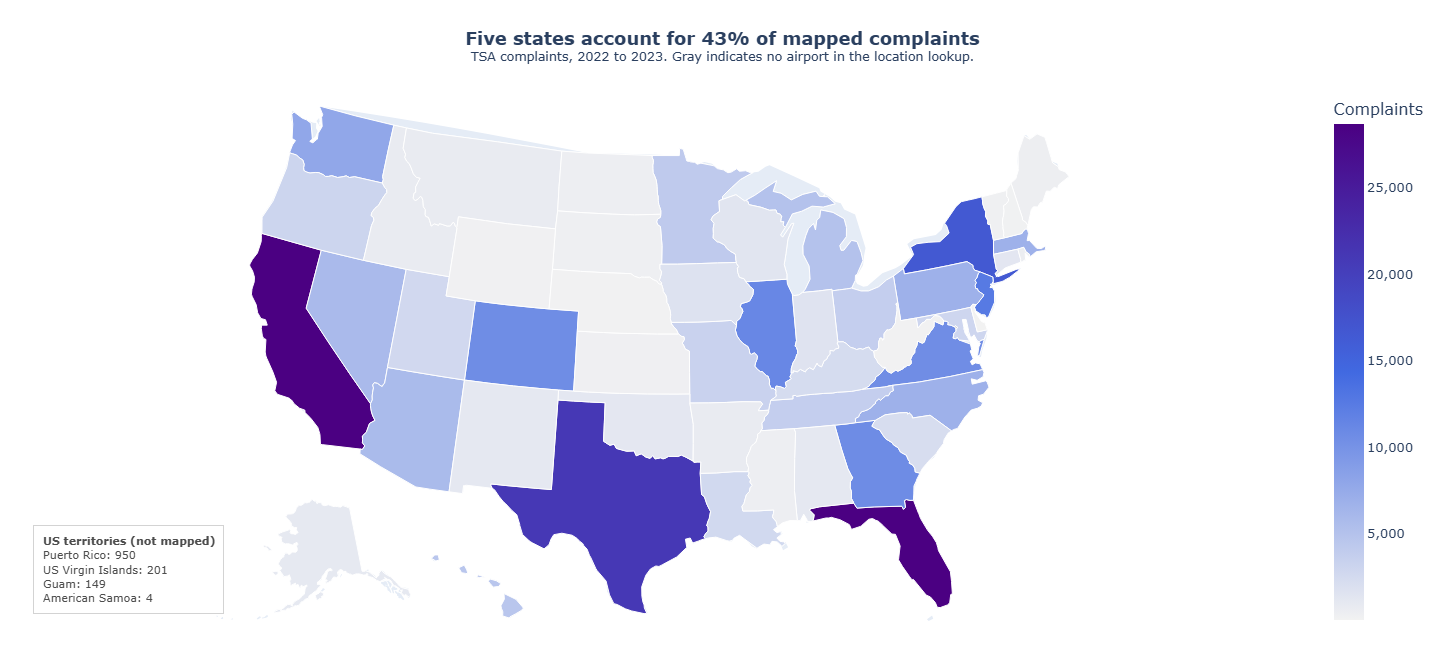

🗺️ Visual 1 saved to figures/viz1_choropleth_state.png
   Top five states carry 107,372 complaints, 43.4% of the mapped total
   States rendered: 50   No-data: 1
   Territories annotated: 4


In [5]:
# Distinguish true no-data jurisdictions from genuine low counts
v1_plot = v1_state[v1_state['complaints'] > 0].copy()
v1_nodata = v1_state[v1_state['complaints'] == 0].copy()

fig1 = px.choropleth(
    v1_plot,
    locations='state_abbr',
    locationmode='USA-states',
    color='complaints',
    scope='usa',
    color_continuous_scale=SEQUENTIAL_CMAP,
    hover_name='state',
    hover_data={'complaints': ':,', 'state_abbr': False},
    labels={'complaints': 'Complaints'},
)

# No-data states get a neutral fill outside the sequential scale
if len(v1_nodata) > 0:
    fig1.add_trace(go.Choropleth(
        locations=v1_nodata['state_abbr'],
        locationmode='USA-states',
        z=[0] * len(v1_nodata),
        colorscale=[[0, LIGHT_GRAY], [1, LIGHT_GRAY]],
        showscale=False,
        hovertext=v1_nodata['state'],
        hoverinfo='text',
        marker_line_color='white',
        marker_line_width=1,
    ))

fig1.update_traces(marker_line_color='white', marker_line_width=1)
fig1.update_layout(
    title={
        'text': (
            '<b>Five states account for 43% of mapped complaints</b><br>'
            '<sup>TSA complaints, 2022 to 2023. '
            'Gray indicates no airport in the location lookup.</sup>'),
        'x': 0.5,
        'xanchor': 'center',
    },
    geo={
        'lakecolor': 'white',
        'bgcolor': 'rgba(0,0,0,0)',
        'showlakes': False},
    margin={
        'r': 20,
        't': 90,
        'l': 20,
        'b': 20},
    width=1100,
    height=650,
    font={
        'size': 13},
    coloraxis_colorbar={
        'title': 'Complaints',
        'tickformat': ','},
)

# Territories fall outside the map projection, so their totals are annotated
if len(v1_territory) > 0:
    terr_lines = '<br>'.join(
        f'{r["name"]}: {r["complaints"]:,}'
        for _, r in v1_territory.iterrows()
    )
    fig1.add_annotation(
        text=f'<b>US territories (not mapped)</b><br>{terr_lines}',
        xref='paper', yref='paper', x=0.01, y=0.03,
        showarrow=False, align='left',
        font={'size': 11, 'color': DARK_GRAY},
        bgcolor='white', bordercolor=LIGHT_GRAY, borderwidth=1, borderpad=8,
    )

fig1.write_image(FIG_DIR / 'viz1_choropleth_state.png', scale=2)
fig1.show()

top5 = v1_plot.head(5)
print('🗺️ Visual 1 saved to figures/viz1_choropleth_state.png')
print(
    f'   Top five states carry {top5["complaints"].sum():,} complaints, '
    f'{top5["complaints"].sum() / v1_plot["complaints"].sum():.1%} of the mapped total')
print(f'   States rendered: {len(v1_plot):,}   No-data: {len(v1_nodata):,}')
print(f'   Territories annotated: {len(v1_territory):,}')

### **Visual 2: When Complaints Arrive**

Monthly complaint volume across all nine complete years. Two structural breaks
shape this grid. The 2020 trough reflects the pandemic collapse in air travel,
and the step change from 2021 onward reflects the TSA Contact Center's move to
Salesforce, which began populating the airport field. Because this view counts
attributed complaints only, the lighter years before 2021 understate true
volume rather than showing fewer complaints.

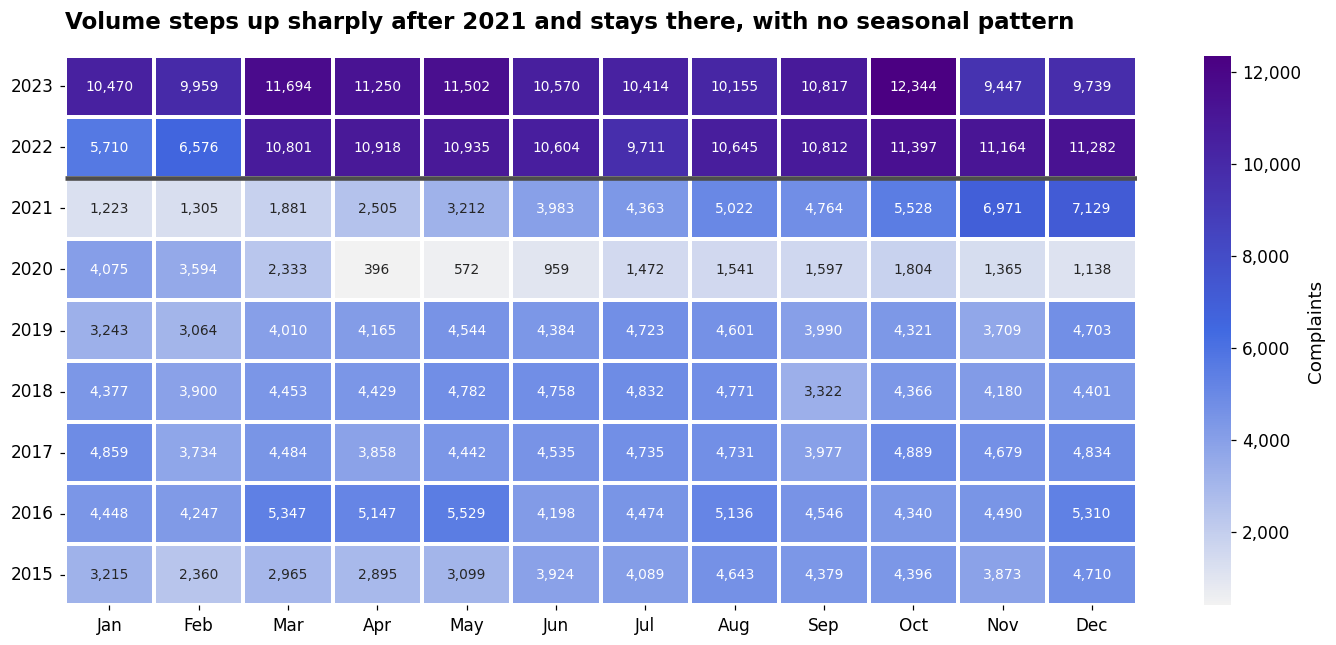

🔥 Visual 2 saved to figures/viz2_heatmap_seasonality.png
   Highest-volume month across all years: Oct
   Highest-volume year: 2023
   Grid: 9 years x 12 months


In [6]:
# Pivot to a year by month grid, with months in calendar order
v2_pivot = (v2_season.pivot(index='year', columns='month', values='complaints')
            .sort_index(ascending=False))
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
v2_pivot.columns = month_order

fig2, ax2 = plt.subplots(figsize=(13, 6))

sns.heatmap(
    v2_pivot,
    cmap=sns.blend_palette(['#F2F2F2', ROYAL_BLUE, PURPLE], as_cmap=True),
    annot=True,
    fmt=',.0f',
    annot_kws={'size': 9},
    linewidths=1.5,
    linecolor='white',
    cbar_kws={'label': 'Complaints', 'format': THOUSANDS},
    ax=ax2,
)

ax2.set_title(
    'Volume steps up sharply after 2021 and stays there, with no seasonal pattern',
    pad=18,
    loc='left',
)
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.tick_params(axis='y', rotation=0)
ax2.grid(False)

# Mark the boundary where the airport field began populating
ax2.hlines(2, 0, 12, color=DARK_GRAY, linewidth=3)

plt.tight_layout()
fig2.savefig(FIG_DIR / 'viz2_heatmap_seasonality.png')
plt.show()

peak_month = v2_season.groupby('month_name')['complaints'].sum().idxmax()
peak_year = v2_season.groupby('year')['complaints'].sum().idxmax()
print('🔥 Visual 2 saved to figures/viz2_heatmap_seasonality.png')
print(f'   Highest-volume month across all years: {peak_month}')
print(f'   Highest-volume year: {peak_year}')
print(f'   Grid: {v2_pivot.shape[0]:,} years x {v2_pivot.shape[1]:,} months')

### **Visual 3: Complaint Load Is Not Proportional to Airport Size**

Distribution of monthly complaint counts per airport for 2022 and 2023. Airports
are grouped by their total complaint volume across the two years, using fixed
thresholds rather than equal-sized groups because the distribution is heavily
concentrated. Each point in a distribution is one airport-month, and the vertical
axis is log-scaled so the lower tiers remain readable alongside the highest. 
Airports in the lowest tier have a median of zero complaints per month. Because
a logarithmic axis cannot display zero, those months are not visible in the
box and the tier appears narrower than it is.

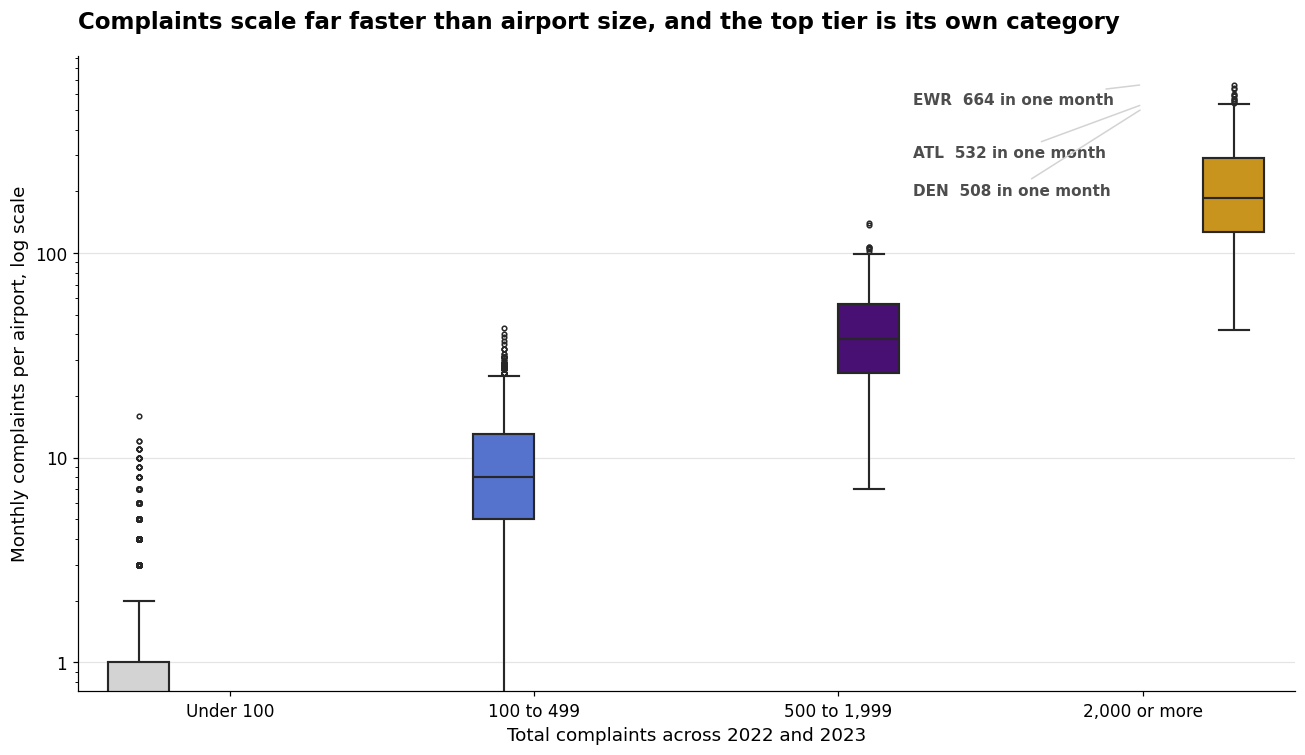

📦 Visual 3 saved to figures/viz3_boxplot_tiers.png
   Under 100 median      0   max      16   5,598 airport-months
   100 to 499 median      8   max      43   1,896 airport-months
   500 to 1,999 median     38   max     140   1,104 airport-months
   2,000 or more median    185   max     664     816 airport-months

   Airport-months plotted: 9,414


In [7]:
# Order tiers smallest to largest for a readable progression
tier_order = ['Under 100', '100 to 499', '500 to 1,999', '2,000 or more']

fig3, ax3 = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=v3_box,
    x='tier',
    y='complaints',
    order=tier_order,
    hue='tier',
    palette=[LIGHT_GRAY, ROYAL_BLUE, PURPLE, AMBER],
    legend=False,
    fliersize=3,
    linewidth=1.4,
    ax=ax3,
)

ax3.set_yscale('log')
ax3.set_title(
    'Complaints scale far faster than airport size, and the top tier is its own category',
    pad=18,
    loc='left',
)
ax3.set_xlabel('Total complaints across 2022 and 2023')
ax3.set_ylabel('Monthly complaints per airport, log scale')
ax3.yaxis.set_major_formatter(THOUSANDS)

# Name the outliers that drive the call to action, offset to avoid overlap
top_airports = list(airport_totals.head(3).index)
for i, code in enumerate(top_airports):
    rows = v3_box[v3_box['airport_code'] == code]
    if len(rows) == 0:
        continue
    peak = rows.loc[rows['complaints'].idxmax()]
    ax3.annotate(
        f'{code}  {peak["complaints"]:,} in one month',
        xy=(tier_order.index(peak['tier']), peak['complaints']),
        xytext=(-150, -10 - i * 22), textcoords='offset points',
        fontsize=10, fontweight='bold', color=DARK_GRAY, va='center',
        arrowprops={'arrowstyle': '-', 'color': LIGHT_GRAY, 'linewidth': 1},
    )

plt.tight_layout()
fig3.savefig(FIG_DIR / 'viz3_boxplot_tiers.png')
plt.show()

tier_stats = (v3_box.groupby('tier', observed=True)['complaints']
              .agg(['median', 'max', 'count']))
print('📦 Visual 3 saved to figures/viz3_boxplot_tiers.png')
for tier in tier_order:
    r = tier_stats.loc[tier]
    print(f'   {tier:<9} median {r["median"]:>6,.0f}   '
          f'max {r["max"]:>7,.0f}   {r["count"]:>5,.0f} airport-months')
print(f'\n   Airport-months plotted: {len(v3_box):,}')

### **Visual 4: What Travelers Complain About Is Shifting**

Share of complaints held by the ten highest-volume subcategories in 2022
compared with 2023. Shares are used rather than raw counts so the comparison is
not distorted by the overall increase in volume between the two years. Each row
shows the two yearly values connected by a bar, with purple marking
subcategories claiming a growing share. Subcategory labels come from the Data
Liberation Project's cleaned field, which resolves truncated names from the
original TSA PDFs.

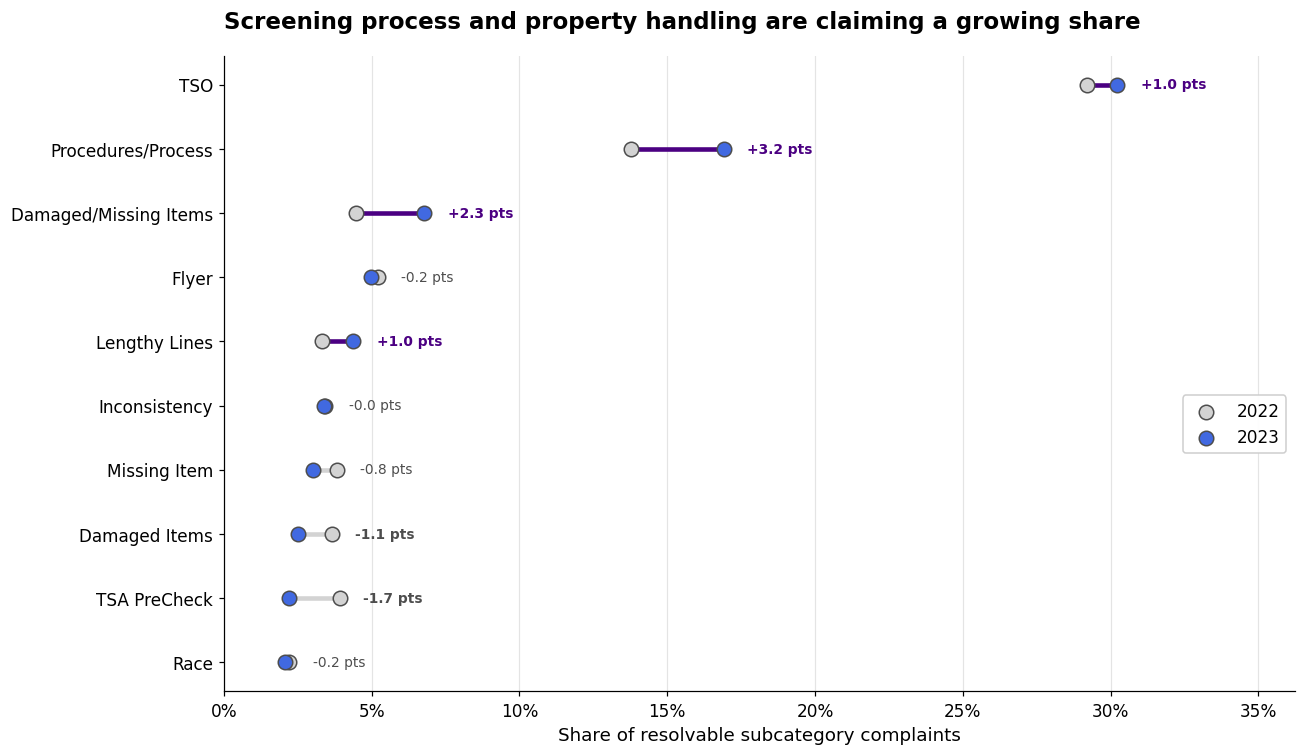

📈 Visual 4 saved to figures/viz4_dumbbell_subcategory.png
   Largest share gain: Procedures/Process (+3.16%)
   Largest share drop: TSA PreCheck (-1.70%)
   Subcategories plotted: 10


In [8]:
# Reshape to one row per subcategory with a column per year
v4_wide = (v4_slope.pivot(index='clean_subcat', columns='year', values='share')
           .dropna())
v4_wide['change'] = v4_wide[2023] - v4_wide[2022]
v4_wide = v4_wide.sort_values(2023)
v4_wide.index = [s.lstrip('*') for s in v4_wide.index]

fig4, ax4 = plt.subplots(figsize=(12, 7))
y_pos = np.arange(len(v4_wide))

# Connector shows direction, endpoint color shows which year
for i, (label, row) in enumerate(v4_wide.iterrows()):
    rising = row['change'] > 0
    ax4.plot([row[2022], row[2023]], [i, i],
             color=PURPLE if rising else LIGHT_GRAY,
             linewidth=3, zorder=2, solid_capstyle='round')

ax4.scatter(v4_wide[2022], y_pos, s=90, color=LIGHT_GRAY,
            edgecolor=DARK_GRAY, linewidth=1, zorder=3, label='2022')
ax4.scatter(v4_wide[2023], y_pos, s=90, color=ROYAL_BLUE,
            edgecolor=DARK_GRAY, linewidth=1, zorder=3, label='2023')

# Label the change at the right edge of each row
for i, (label, row) in enumerate(v4_wide.iterrows()):
    x = max(row[2022], row[2023])
    ax4.text(x + 0.008, i, f'{row["change"] * 100:+.1f} pts',
             va='center', fontsize=9,
             color=PURPLE if row['change'] > 0 else DARK_GRAY,
             fontweight='bold' if abs(row['change']) > 0.01 else 'normal')

ax4.set_yticks(y_pos)
ax4.set_yticklabels(v4_wide.index, fontsize=11)
ax4.set_xlim(0, v4_wide[[2022, 2023]].max().max() + 0.06)
ax4.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0%}')
)
ax4.set_xlabel('Share of resolvable subcategory complaints')
ax4.set_ylabel('')
ax4.set_title(
    'Screening process and property handling are claiming a growing share',
    pad=18, loc='left',
)
ax4.legend(loc='center right', frameon=True, framealpha=0.95,
           bbox_to_anchor=(1.0, 0.42))
ax4.grid(axis='y', visible=False)

plt.tight_layout()
fig4.savefig(FIG_DIR / 'viz4_dumbbell_subcategory.png')
plt.show()

biggest_gain = v4_wide['change'].idxmax()
biggest_drop = v4_wide['change'].idxmin()
print('📈 Visual 4 saved to figures/viz4_dumbbell_subcategory.png')
print(f'   Largest share gain: {biggest_gain} '
      f'({v4_wide.loc[biggest_gain, "change"]:+.2%})')
print(f'   Largest share drop: {biggest_drop} '
      f'({v4_wide.loc[biggest_drop, "change"]:+.2%})')
print(f'   Subcategories plotted: {len(v4_wide):,}')

### **Visual 5: The Complaint Mix Varies by Airport**

Category composition of complaints at the ten highest-volume airports, 2022 and
2023 combined. Bars are normalized to 100% so the comparison is about mix rather
than volume, since Newark and Atlanta would otherwise dwarf the rest. Categories
outside the top seven by national volume are grouped as Other.

Complaints in the Expedited Passenger Screening Program category, which covers
PreCheck enrollment and membership rather than checkpoint operations, are
excluded. That category accounts for 63 to 88 percent of complaints at these
airports and is handled centrally, so including it would obscure the
operational differences this comparison is meant to show.

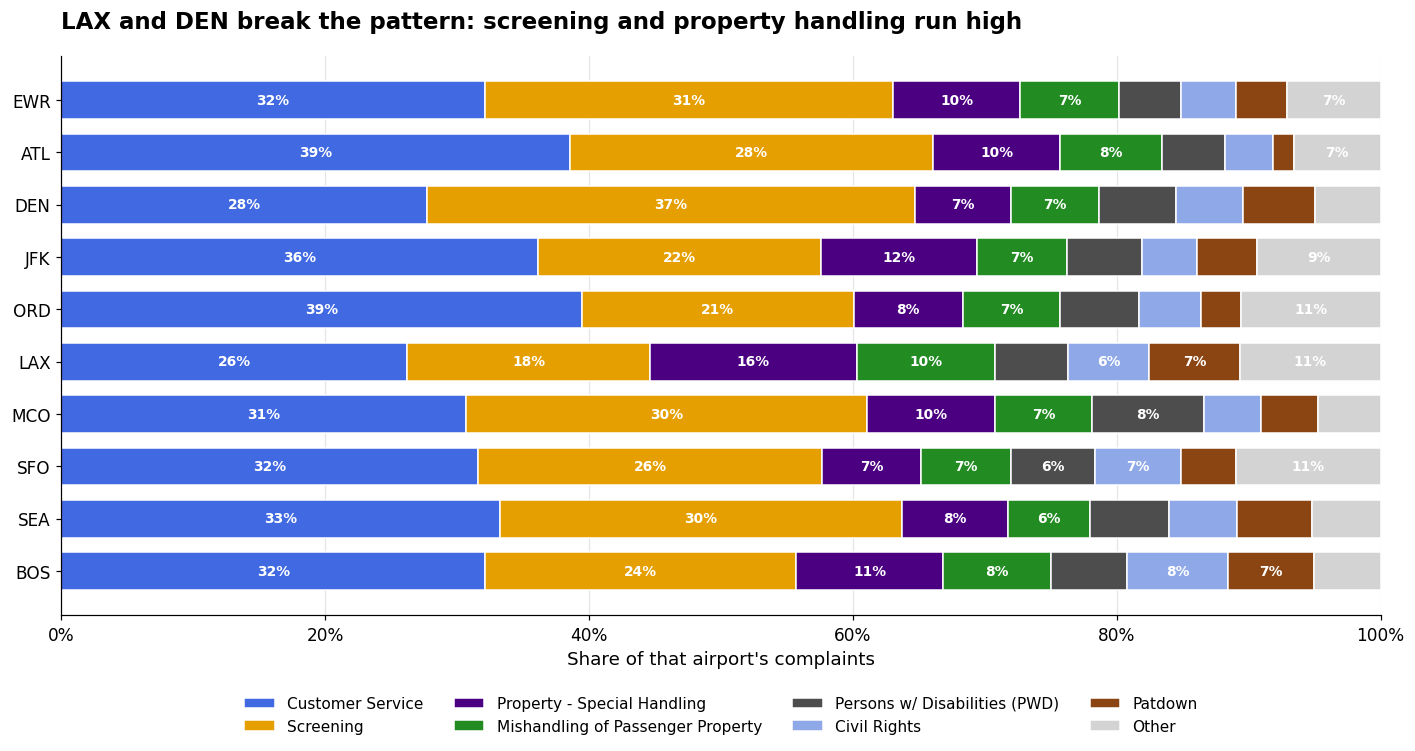

📊 Visual 5 saved to figures/viz5_stackedbar_mix.png
   Airports shown: 10
   Categories: 8 including Other
   Highest Customer Service: ORD at 39.4%
   Highest Screening: DEN at 37.0%
   Highest Property - Special Handling: LAX at 15.7%


In [9]:
# Keep the seven largest remaining categories and group the long tail
top_cats = (v5_mix.groupby('clean_cat')['complaints'].sum()
            .nlargest(7).index)
v5_plot = v5_mix.copy()
v5_plot['category'] = v5_plot['clean_cat'].where(
    v5_plot['clean_cat'].isin(top_cats), 'Other'
)

# Pivot to airports as rows and categories as columns, converted to shares
v5_pivot = (v5_plot.groupby(['airport_code', 'category'])['complaints'].sum()
            .unstack(fill_value=0))
cat_order = [c for c in top_cats] + ['Other']
v5_pivot = v5_pivot.reindex(columns=cat_order, fill_value=0)
v5_pivot = v5_pivot.loc[airport_totals.head(10).index]
v5_share = v5_pivot.div(v5_pivot.sum(axis=1), axis=0)

fig5, ax5 = plt.subplots(figsize=(13, 7))
colors = [ROYAL_BLUE, AMBER, PURPLE, FOREST_GREEN, DARK_GRAY,
          '#8FA9E8', '#8B4513', LIGHT_GRAY]

left = np.zeros(len(v5_share))
for col, color in zip(cat_order, colors):
    vals = v5_share[col].values
    ax5.barh(v5_share.index, vals, left=left, color=color,
             label=col, height=0.72, edgecolor='white', linewidth=1)

    # Label only segments wide enough to hold text
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 0.06:
            ax5.text(l + v / 2, i, f'{v:.0%}', ha='center', va='center',
                     fontsize=9, color='white', fontweight='bold')
    left += vals

ax5.set_xlim(0, 1)
ax5.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0%}')
)
ax5.invert_yaxis()
ax5.set_xlabel('Share of that airport\'s complaints')
ax5.set_ylabel('')
ax5.set_title(
    'LAX and DEN break the pattern: screening and property handling run high',
    pad=18, loc='left',
)
ax5.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
           ncol=4, frameon=False, fontsize=10)
ax5.grid(axis='y', visible=False)

plt.tight_layout()
fig5.savefig(FIG_DIR / 'viz5_stackedbar_mix.png')
plt.show()

print('📊 Visual 5 saved to figures/viz5_stackedbar_mix.png')
print(f'   Airports shown: {len(v5_share):,}')
print(f'   Categories: {len(cat_order):,} including Other')
for col in cat_order[:3]:
    hi = v5_share[col].idxmax()
    print(f'   Highest {col}: {hi} at {v5_share.loc[hi, col]:.1%}')

### **Visual 6: Volume Rose Sharply, and the Data Got Better at the Same Time**

National monthly complaint totals across all nine complete years, with the share
of complaints naming an airport plotted on the secondary axis. This is the only
visual using the full complaint universe rather than the attributed subset,
which is why it can show both the volume trend and the reporting change that
constrains every other view in this analysis.

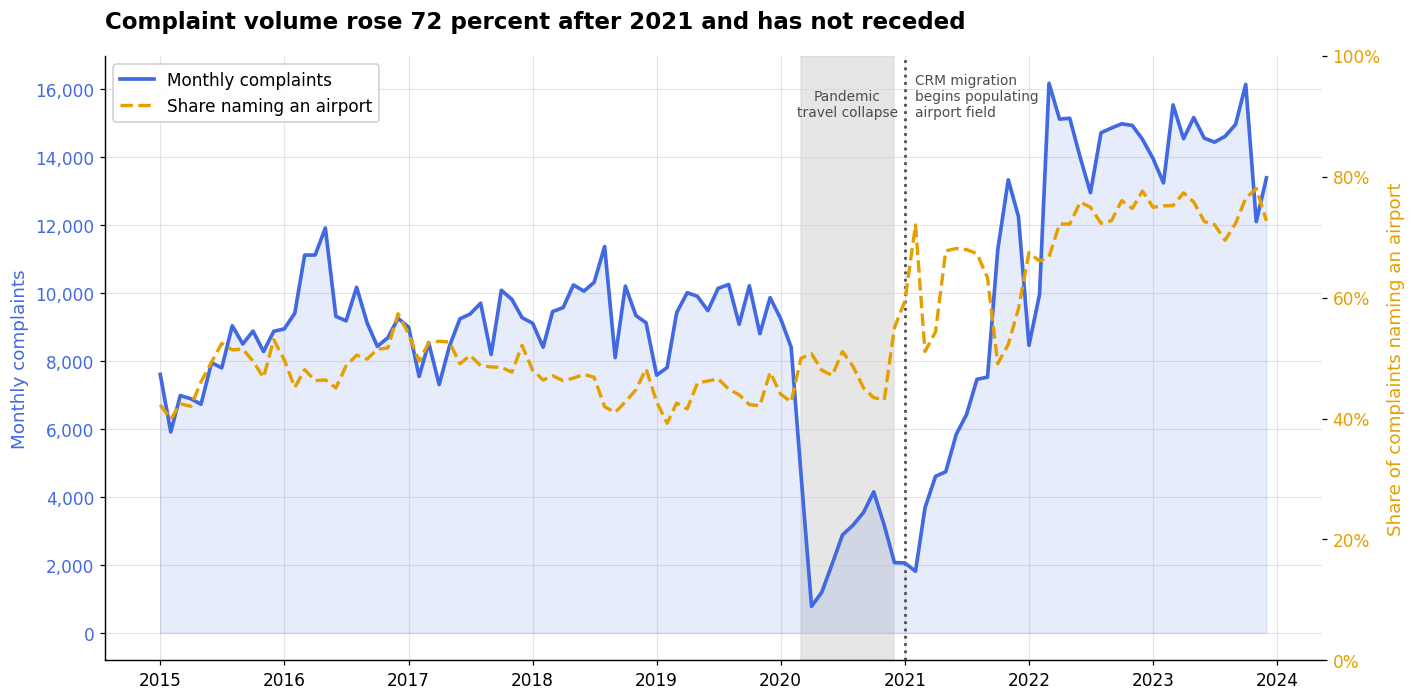

📉 Visual 6 saved to figures/viz6_line_trend.png
   Mean monthly complaints, 2015 to 2020: 8,195
   Mean monthly complaints, 2022 to 2023: 14,109
   Increase: +72%
   Attribution rate, first month: 42%
   Attribution rate, last month: 73%


In [10]:
fig6, ax6 = plt.subplots(figsize=(13, 6.5))

# Total volume carries the primary axis
ax6.plot(v6_trend['date'], v6_trend['total'], color=ROYAL_BLUE,
         linewidth=2.4, zorder=3, label='Monthly complaints')
ax6.fill_between(v6_trend['date'], v6_trend['total'], color=ROYAL_BLUE,
                 alpha=0.12, zorder=2)

ax6.set_ylabel('Monthly complaints', color=ROYAL_BLUE)
ax6.tick_params(axis='y', labelcolor=ROYAL_BLUE)
ax6.yaxis.set_major_formatter(THOUSANDS)
ax6.set_xlabel('')

# Attribution rate rides a secondary axis to expose the reporting change
ax7 = ax6.twinx()
ax7.plot(v6_trend['date'], v6_trend['attributed_pct'], color=AMBER,
         linewidth=2.2, linestyle='--', zorder=3,
         label='Share naming an airport')
ax7.set_ylabel('Share of complaints naming an airport', color=AMBER)
ax7.tick_params(axis='y', labelcolor=AMBER)
ax7.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0%}')
)
ax7.set_ylim(0, 1)
ax7.grid(False)

# Mark the two events that explain the shape of both lines
ax6.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-01'),
            color=LIGHT_GRAY, alpha=0.55, zorder=1)
ax6.text(pd.Timestamp('2020-07-15'), v6_trend['total'].max() * 0.94,
         'Pandemic\ntravel collapse', ha='center', fontsize=9,
         color=DARK_GRAY)

ax6.axvline(pd.Timestamp('2021-01-01'), color=DARK_GRAY,
            linestyle=':', linewidth=1.8, zorder=2)
ax6.text(pd.Timestamp('2021-02-01'), v6_trend['total'].max() * 0.94,
         'CRM migration\nbegins populating\nairport field', fontsize=9,
         color=DARK_GRAY)

ax6.set_title(
    'Complaint volume rose 72 percent after 2021 and has not receded',
    pad=18, loc='left',
)

lines = ax6.get_lines()[:1] + ax7.get_lines()[:1]
ax6.legend(lines, [l.get_label() for l in lines], loc='upper left',
           frameon=True, framealpha=0.95)

plt.tight_layout()
fig6.savefig(FIG_DIR / 'viz6_line_trend.png')
plt.show()

pre = v6_trend[v6_trend['date'] < '2021-01-01']['total'].mean()
post = v6_trend[v6_trend['date'] >= '2022-01-01']['total'].mean()
print('📉 Visual 6 saved to figures/viz6_line_trend.png')
print(f'   Mean monthly complaints, 2015 to 2020: {pre:,.0f}')
print(f'   Mean monthly complaints, 2022 to 2023: {post:,.0f}')
print(f'   Increase: {post / pre - 1:+.0%}')
print(f'   Attribution rate, first month: '
      f'{v6_trend["attributed_pct"].iloc[0]:.0%}')
print(f'   Attribution rate, last month: '
      f'{v6_trend["attributed_pct"].iloc[-1]:.0%}')

<br><br><br><br><br><br><br><br><br><br><br><br><br><br>

### **Summary Paper**

**Audience, purpose, and medium**

I built this analysis for TSA Office of Security Operations leadership and the
Federal Security Directors who run checkpoint operations at high-volume
airports. These are stakeholders already fluent in the data, so I kept
checkpoint terminology intact rather than defining it. My purpose is not to
report that complaints exist but to argue that they concentrate predictably
enough to staff against. Five states carry 43 percent of located complaints,
and airports above 2,000 complaints behave as a separate population whose
median month exceeds the maximum month of the tier below. My call to action is
to fund a targeted property handling and screening process intervention at the
ten highest-volume airports, with Denver and Los Angeles prioritized because
their complaint mix diverges most sharply from peers. The medium is an
executive slide deck drawn from these figures, with the notebook retained as
the analytic appendix.

**Design decisions**

I relied on proximity and similarity to carry meaning. In the stacked bar,
consistent category ordering across airports lets the eye track a single band
horizontally rather than rereading each row. Color is a colorblind-safe
sequence of royal blue, amber, purple, forest green, and brown, with light gray
reserved exclusively for absent or residual values so that gray never competes
with a data color. Every title states the finding rather than the topic, which
follows Knaflic's (2015) argument that the takeaway belongs in the headline.
Left alignment across titles and axis labels creates a single vertical edge, and
generous white space between box plot tiers keeps four distributions legible
without gridline clutter.

**Ethical considerations**

The data arrived through a Freedom of Information Act pipeline maintained by the
Data Liberation Project (2023), which converts TSA's published PDFs into
structured files, joined to airport locations from IP2Location (2024). Both are
public and lawfully obtained. My transformations are labeled in the notebook
rather than buried. I restricted airport-level visuals to 2022 and 2023 because
attribution rises from roughly 45 percent to 74 percent after TSA's contact
center migrated to Salesforce, a measurement change that would otherwise read as
a behavioral surge. I excluded fourteen unresolvable airport codes carrying
0.111 percent of complaints, a subcategory placeholder representing three
quarters of subcategory volume, and PreCheck enrollment complaints from the
airport mix comparison. The chief risk is that concentration invites punitive
resource decisions against named airports when raw counts lack a passenger
denominator. I mitigated this by framing tiers as operational populations rather
than rankings and by recommending intervention rather than sanction. Adding
throughput data would strengthen the claim, and I would pursue that before
presenting to leadership.

# Reflection

## General Reflection
This week’s TSA complaint analysis felt like the most “real‑world operations” assignment of the course so far. Working with four separate datasets—each with its own quirks, missingness, and structural inconsistencies—pushed me to think less like a student and more like an analyst preparing a briefing for leadership. The biggest shift was recognizing that the story couldn’t simply be about complaint counts; it had to be about *where* complaints concentrate, *how* reporting changed over time, and *what* patterns were strong enough to justify a call to action. The Salesforce migration in late 2020 fundamentally reshaped the data, and acknowledging that measurement change became just as important as analyzing the complaints themselves.

Crafting the visuals required balancing clarity with operational nuance. The choropleth made geographic concentration obvious, the heat map exposed structural breaks, and the box plot revealed how dramatically the top-tier airports separate from the rest. The dumbbell chart and stacked bar added behavioral texture—what travelers complain about and how that mix shifts by airport. Pulling these together into a coherent narrative reinforced how design choices directly shape comprehension, especially for an audience already fluent in TSA terminology.

Overall, this assignment strengthened my ability to merge data cleaning, visual storytelling, and operational framing into a single analytic product. It also highlighted how ethical transparency—labeling exclusions, explaining attribution limits, and avoiding misleading comparisons—is essential when the output could influence resource decisions.

## Straightforward Aspects
- Profiling the four datasets and confirming reconciliation across files was direct and helped establish trust in the data early.
- Joining airport codes to the IATA/ICAO lookup was clean once US territories were added back in.
- Building the six required visuals felt natural thanks to the structured analysis frames created in Python.
- Identifying the modern reliable years (2022–2023) was simple once the attribution rate by year was plotted.

## Challenging Aspects
- Handling the massive subcategory placeholder (“*”) required careful exclusion and clear documentation since it represented nearly three quarters of the subcategory volume.
- Designing visuals that communicated both volume and reporting changes without misleading the audience took deliberate thought.
- Ensuring the call to action was grounded in data rather than punitive ranking required reframing airports as operational tiers rather than winners and losers.
- Balancing Gestalt principles—especially spacing, alignment, and color consistency—was more complex with six distinct visual types.
